In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import math, numpy as np
import re
import seaborn as sns

In [12]:
time_cache = '../data/outs/03282/all_time_cache.csv'
ops = '../data/outs/03282/all_ops.csv'

try:
    df_tcache = pd.read_csv(time_cache, sep=' ')
    df_ops = pd.read_csv(ops, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado!")

Dados lidos com sucesso!


In [13]:
df_tcache.dtypes

nome           object
n               int64
m               int64
c               int64
insert          int64
extractMin      int64
dk              int64
bkmp            int64
upd             int64
fila           object
cpu_time        int64
wall_time       int64
l1_ac           int64
l1_miss         int64
llc_ac          int64
llc_miss        int64
cycles          int64
inst            int64
dtlb            int64
page_faults     int64
branch_inst     int64
branch_miss     int64
dtype: object

In [14]:
# selecionar todos que não são MEM

df_tcache = df_tcache[df_tcache["nome"].str.startswith("MEM")]

## Tabela do maior C

In [15]:
df_usa = df_tcache[df_tcache["nome"] == "MEM8"]
df_usa.head()

,nome,n,m,c,insert,extractMin,dk,bkmp,upd,fila,...,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
2380,MEM8,100000,500000,99999791,147103,147103,0,469772623,0,1LVBQ,...,8464539049,160429927,2881950,1898734,3409000657,14354476583,230497,0,1720867814,368846
2381,MEM8,100000,500000,99999791,146896,146896,0,412049331,0,1LVBQ,...,7440118009,141251478,2726574,1733538,3003563447,12624581225,228846,0,1516487469,367236
2382,MEM8,100000,500000,99999791,146840,146840,0,442087232,0,1LVBQ,...,7970784010,151193601,2804900,1802081,3211416218,13521984589,228223,0,1622632229,360329
2383,MEM8,100000,500000,99999791,146882,146882,0,435108585,0,1LVBQ,...,7850610436,148907716,2788812,1801677,3160227675,13296922319,226514,0,1596600557,352845
2384,MEM8,100000,500000,99999791,146910,146910,0,439345868,0,1LVBQ,...,7925458828,150315723,2810930,1809365,3193398660,13448685352,229826,0,1612512912,367336


In [16]:
df_usa = df_usa.groupby("fila").mean(numeric_only=True)
df_usa

,n,m,c,insert,extractMin,dk,bkmp,upd,cpu_time,wall_time,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
fila,,,,,,,,,,,,,,,,,,,,
1LVBQ,100000.0,500000.0,99999791.0,132279.7,132279.7,0.0,396232872.7,0.0,1334.1,1334.2,7.146866e+09,135569870.7,2524616.2,1627840.6,2.878801e+09,1.211968e+10,204995.9,0.0,1.454224e+09,328768.4
1LVBQDK,100000.0,500000.0,99999791.0,147149.9,100000.0,47149.9,444487876.5,0.0,979.4,979.5,5.992901e+09,52370009.7,1849102.2,835470.6,2.273167e+09,8.442463e+09,156685.9,0.0,8.132236e+08,249515.5
2LVBQ,100000.0,500000.0,99999791.0,147108.5,147108.5,0.0,171080389.4,12738.1,2090.3,2090.5,8.941592e+09,60303235.3,833699.9,125535.3,4.469801e+09,1.805804e+10,76432.7,0.0,3.547879e+09,452197.6
2LVBQDK,100000.0,500000.0,99999791.0,147128.3,100000.0,47128.3,151478025.5,11728.0,326.2,326.3,2.099133e+09,19243012.8,812958.1,103526.3,7.744543e+08,2.692745e+09,54539.6,0.0,2.943029e+08,302353.3
3LVBQ,100000.0,500000.0,99999791.0,147103.1,147103.1,0.0,574525.3,1291.6,56.9,56.9,1.746033e+08,2097960.1,511018.5,79692.0,1.304701e+08,3.668797e+08,51590.1,0.0,6.303416e+07,328692.3
3LVBQDK,100000.0,500000.0,99999791.0,147098.8,100000.0,47098.8,559712.6,1275.0,41.7,41.7,1.098887e+08,2495300.3,724408.1,95406.8,1.031288e+08,2.194423e+08,56653.2,0.0,2.753762e+07,326208.6
4LVBQ,100000.0,500000.0,99999791.0,147191.6,147191.6,0.0,1367940.3,12780.8,73.8,73.8,2.478625e+08,1803250.5,511981.3,80423.1,1.660968e+08,5.139669e+08,45514.3,0.0,8.652927e+07,347953.5
4LVBQDK,100000.0,500000.0,99999791.0,147057.6,100000.3,47057.3,1213851.1,11779.9,47.4,47.4,1.375285e+08,2493092.1,746609.6,97456.2,1.127661e+08,2.620942e+08,56107.7,0.0,2.988645e+07,319263.0
5LVBQ,100000.0,500000.0,99999791.0,147104.7,147104.7,0.0,1876482.6,39014.1,85.6,85.6,2.969675e+08,1796206.0,505267.4,76516.2,1.936880e+08,6.175089e+08,44104.1,0.0,1.015732e+08,369526.0


In [17]:
df_usa = df_usa.copy()
df_usa.head()

df_usa["ipc"] = df_usa["inst"] / df_usa["cycles"]

colunas = [
    "cpu_time", "wall_time", "l1_ac", "l1_miss",
    "llc_ac", "llc_miss", "branch_inst", "branch_miss", "inst", "bkmp"
]

df_usa = df_usa[colunas]

In [18]:
mins = df_usa.min()

mins["bkmp"] = df_usa.loc[df_usa["bkmp"] != 0, "bkmp"].min()

mins
df_norm = df_usa / mins

In [19]:
df_norm.style.highlight_min(axis=0, color="lightgreen").highlight_max(axis=0, color="salmon")

,cpu_time,wall_time,l1_ac,l1_miss,llc_ac,llc_miss,branch_inst,branch_miss,inst,bkmp
fila,,,,,,,,,,
1LVBQ,31.992806,31.995204,65.037284,76.965687,4.996594,21.274457,52.808619,1.317627,55.229479,707.922017
1LVBQDK,23.486811,23.489209,54.536072,29.731487,3.659651,10.918872,29.531371,1.000000,38.472356,794.135913
2LVBQ,50.127098,50.131894,81.369493,34.235335,1.650017,1.640637,128.837549,1.812303,82.290624,305.657563
2LVBQDK,7.822542,7.824940,19.102344,10.924638,1.608966,1.352998,10.687305,1.211762,12.270858,270.635368
3LVBQ,1.364508,1.364508,1.588910,1.191053,1.011382,1.041505,2.289020,1.317322,1.671873,1.026465
3LVBQDK,1.000000,1.000000,1.000000,1.416631,1.433712,1.246884,1.000000,1.307368,1.000000,1.000000
4LVBQ,1.769784,1.769784,2.255577,1.023741,1.013288,1.051060,3.142220,1.394517,2.342150,2.444005
4LVBQDK,1.136691,1.136691,1.251525,1.415378,1.477652,1.273668,1.085295,1.279532,1.194365,2.168704
5LVBQ,2.052758,2.052758,2.702437,1.019742,1.000000,1.000000,3.688524,1.480974,2.813992,3.352582


In [20]:
latex = df_norm.to_latex(
    index=True,
    float_format="%.2f",
    longtable=False,
    escape=False
)

print(latex)

\begin{tabular}{lrrrrrrrrrr}
\toprule
 & cpu_time & wall_time & l1_ac & l1_miss & llc_ac & llc_miss & branch_inst & branch_miss & inst & bkmp \\
fila &  &  &  &  &  &  &  &  &  &  \\
\midrule
1LVBQ & 31.99 & 32.00 & 65.04 & 76.97 & 5.00 & 21.27 & 52.81 & 1.32 & 55.23 & 707.92 \\
1LVBQDK & 23.49 & 23.49 & 54.54 & 29.73 & 3.66 & 10.92 & 29.53 & 1.00 & 38.47 & 794.14 \\
2LVBQ & 50.13 & 50.13 & 81.37 & 34.24 & 1.65 & 1.64 & 128.84 & 1.81 & 82.29 & 305.66 \\
2LVBQDK & 7.82 & 7.82 & 19.10 & 10.92 & 1.61 & 1.35 & 10.69 & 1.21 & 12.27 & 270.64 \\
3LVBQ & 1.36 & 1.36 & 1.59 & 1.19 & 1.01 & 1.04 & 2.29 & 1.32 & 1.67 & 1.03 \\
3LVBQDK & 1.00 & 1.00 & 1.00 & 1.42 & 1.43 & 1.25 & 1.00 & 1.31 & 1.00 & 1.00 \\
4LVBQ & 1.77 & 1.77 & 2.26 & 1.02 & 1.01 & 1.05 & 3.14 & 1.39 & 2.34 & 2.44 \\
4LVBQDK & 1.14 & 1.14 & 1.25 & 1.42 & 1.48 & 1.27 & 1.09 & 1.28 & 1.19 & 2.17 \\
5LVBQ & 2.05 & 2.05 & 2.70 & 1.02 & 1.00 & 1.00 & 3.69 & 1.48 & 2.81 & 3.35 \\
5LVBQDK & 1.10 & 1.10 & 1.29 & 1.33 & 1.30 & 1.13 & 1.04

# Tempo de execução

In [21]:
df_tcache.head()

,nome,n,m,c,insert,extractMin,dk,bkmp,upd,fila,...,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
1680,MEM3,100000,500000,1000,144786,144786,0,1604,0,1LVBQ,...,84450736,1817367,510645,104545,85451197,183982026,47651,0,35290409,191398
1681,MEM3,100000,500000,1000,144814,144814,0,1776,0,1LVBQ,...,84452145,1821941,516403,90613,81281992,179157486,50189,0,34917823,189783
1682,MEM3,100000,500000,1000,144833,144833,0,1761,0,1LVBQ,...,84070812,1809828,510546,82064,80754363,184822668,48318,0,35525377,193746
1683,MEM3,100000,500000,1000,144846,144846,0,1742,0,1LVBQ,...,84286186,1811257,507888,83333,81403650,184674673,50518,0,34904804,193239
1684,MEM3,100000,500000,1000,145086,145086,0,2012,0,1LVBQ,...,84336146,1817994,508376,82341,80872861,185211331,48454,0,35660188,194133


### Perguntas

#### Gerais
- Em média, quanto extractMin a mais são realizados em filas sem DK? (incluir DK)
- Quem realiza mais/menos instruções por instância?
- Quem tem mais cache miss (total e rate) por instância?
- Quem tem mais branch miss (total e rate) por instância?
- Dtlb e page faults tem alguma relevância?

#### Buckets
- Quantos buckets vazios cada estrutura avalia?
- Quantas operações de expansão são realizadas?
- Quantos updates cada estrutura realiza?
- Qual bucket tem mais/menos branch miss (total e rate) por instância?
- Quel bucket tem mais/menos cache miss (total e rate) por instância?


In [22]:
df_time = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time', 'wall_time']
].copy()
df_time

,nome,n,c,fila,cpu_time,wall_time
1680,MEM3,100000,1000,1LVBQ,35,35
1681,MEM3,100000,1000,1LVBQ,35,35
1682,MEM3,100000,1000,1LVBQ,34,34
1683,MEM3,100000,1000,1LVBQ,34,34
1684,MEM3,100000,1000,1LVBQ,34,34
...,...,...,...,...,...,...
2515,MEM8,100000,99999791,FIBH,110,110
2516,MEM8,100000,99999791,FIBH,109,109
2517,MEM8,100000,99999791,FIBH,108,108
2518,MEM8,100000,99999791,FIBH,110,110


In [23]:
df_time["wall_cpu_ratio"] = df_time["wall_time"] / df_time["cpu_time"]
print("Min ratio", df_time["wall_cpu_ratio"].min())
print("Max ratio", df_time["wall_cpu_ratio"].max())

Min ratio 1.0
Max ratio 1.027027027027027


Logo, CPU Bound

In [24]:
df_cpu = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time']
].copy()
df_cpu = (
    df_cpu.groupby(['nome', 'fila'], as_index=False)
      .agg(
           cpu_mean=('cpu_time', 'mean'),
           cpu_std =('cpu_time', 'std'),
           cpu_var =('cpu_time', 'var'),
           c=('c', 'first'),
      )
)
df_cpu['cpu_cv'] = df_cpu['cpu_std'] / df_cpu['cpu_mean']
df_cpu

,nome,fila,cpu_mean,cpu_std,cpu_var,c,cpu_cv
0,MEM3,1LVBQ,34.5,0.707107,0.500000,1000,0.020496
1,MEM3,1LVBQDK,30.3,0.483046,0.233333,1000,0.015942
2,MEM3,2LVBQ,37.7,0.483046,0.233333,1000,0.012813
3,MEM3,2LVBQDK,35.3,1.059350,1.122222,1000,0.030010
4,MEM3,3LVBQ,44.8,0.421637,0.177778,1000,0.009412
...,...,...,...,...,...,...,...
79,MEM8,5LVBQDK,45.8,16.095548,259.066667,99999791,0.351431
80,MEM8,6LVBQ,93.9,0.567646,0.322222,99999791,0.006045
81,MEM8,6LVBQDK,54.0,0.000000,0.000000,99999791,0.000000
82,MEM8,BINH,89.7,0.674949,0.455556,99999791,0.007525


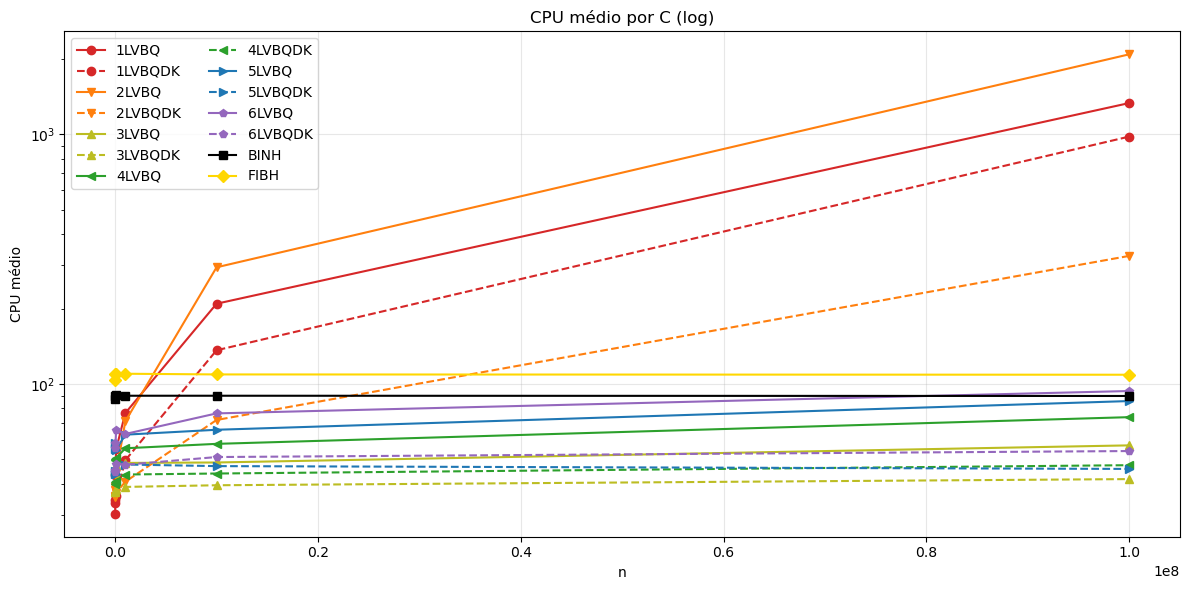

In [25]:

# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("c")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["c"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por C (log)")
plt.yscale("log")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== estilos =====
    if fila == "BINH":
        color = "black"
        mark = "square*"

    elif fila == "FIBH":
        color = "gold"
        mark = "diamond*"

    else:
        nivel = int(re.match(r"\d+", fila).group())

        cores = {
            1: "red",
            2: "orange",
            3: "olive",
            4: "green",
            5: "blue",
            6: "purple",
        }

        color = cores[nivel]

        mark_map = {
            1: "*",
            2: "triangle*",
            3: "triangle*",
            4: "triangle*",
            5: "triangle*",
            6: "pentagon*",
        }

        mark = mark_map[nivel]

    print(f"% --- {fila} ---")
    print(rf"\addplot[color={color}, mark={mark}]")
    print("coordinates {")

    for _, row in dados.iterrows():
        print(f"  ({int(row['c'])},{row['cpu_mean']:.1f})")

    print("};")
    print(rf"\addlegendentry{{{fila}}}")
    print()

% --- 1LVBQ ---
\addplot[color=red, mark=*]
coordinates {
  (1000,34.5)
  (10000,43.2)
  (100000,55.0)
  (999998,76.6)
  (9999980,209.9)
  (99999791,1334.1)
};
\addlegendentry{1LVBQ}

% --- 1LVBQDK ---
\addplot[color=red, mark=*]
coordinates {
  (1000,30.3)
  (10000,33.6)
  (100000,35.7)
  (999998,49.6)
  (9999980,136.7)
  (99999791,979.4)
};
\addlegendentry{1LVBQDK}

% --- 2LVBQ ---
\addplot[color=orange, mark=triangle*]
coordinates {
  (1000,37.7)
  (10000,38.9)
  (100000,44.0)
  (999998,71.0)
  (9999980,293.6)
  (99999791,2090.3)
};
\addlegendentry{2LVBQ}

% --- 2LVBQDK ---
\addplot[color=orange, mark=triangle*]
coordinates {
  (1000,35.3)
  (10000,35.8)
  (100000,36.8)
  (999998,40.7)
  (9999980,71.9)
  (99999791,326.2)
};
\addlegendentry{2LVBQDK}

% --- 3LVBQ ---
\addplot[color=olive, mark=triangle*]
coordinates {
  (1000,44.8)
  (10000,44.0)
  (100000,47.5)
  (999998,48.4)
  (9999980,48.6)
  (99999791,56.9)
};
\addlegendentry{3LVBQ}

% --- 3LVBQDK ---
\addplot[color=olive, mark=t

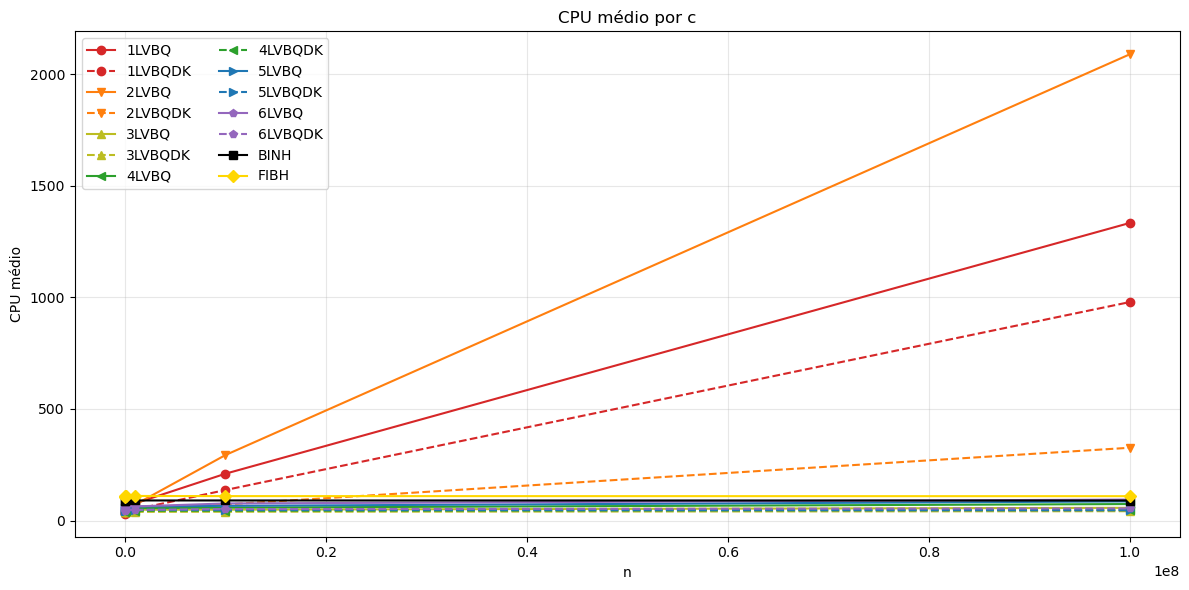

In [27]:

# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("c")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["c"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por c")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

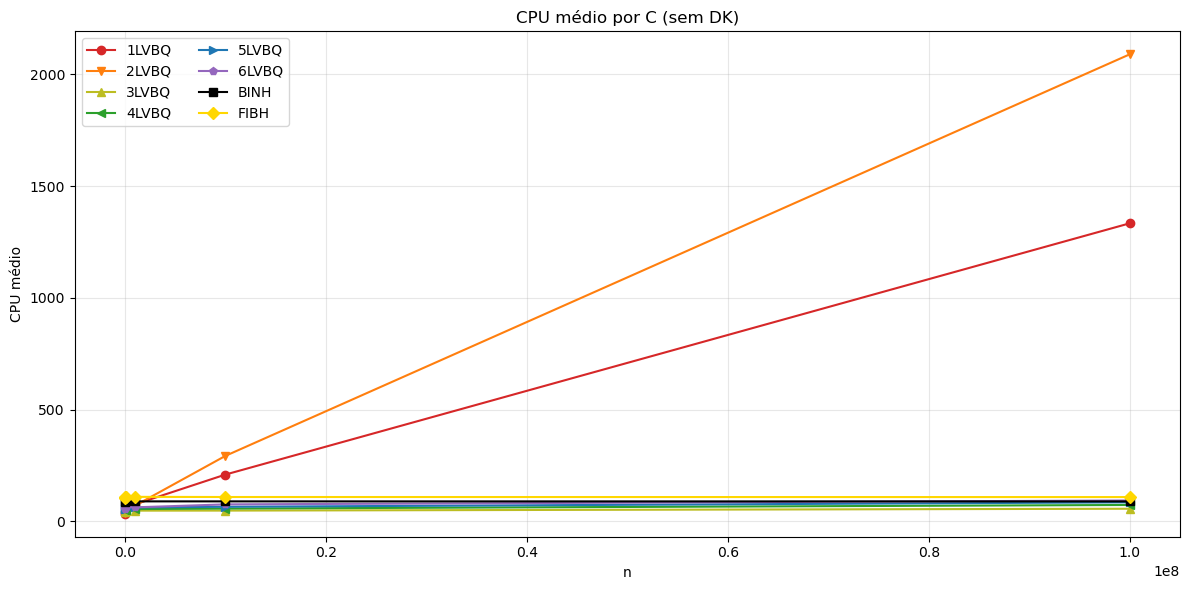

In [28]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **sem DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ$"))  # somente LVBQ sem DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("c")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ simples (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "-"  # todas LVBQ simples são sólidas
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["c"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por C (sem DK)")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

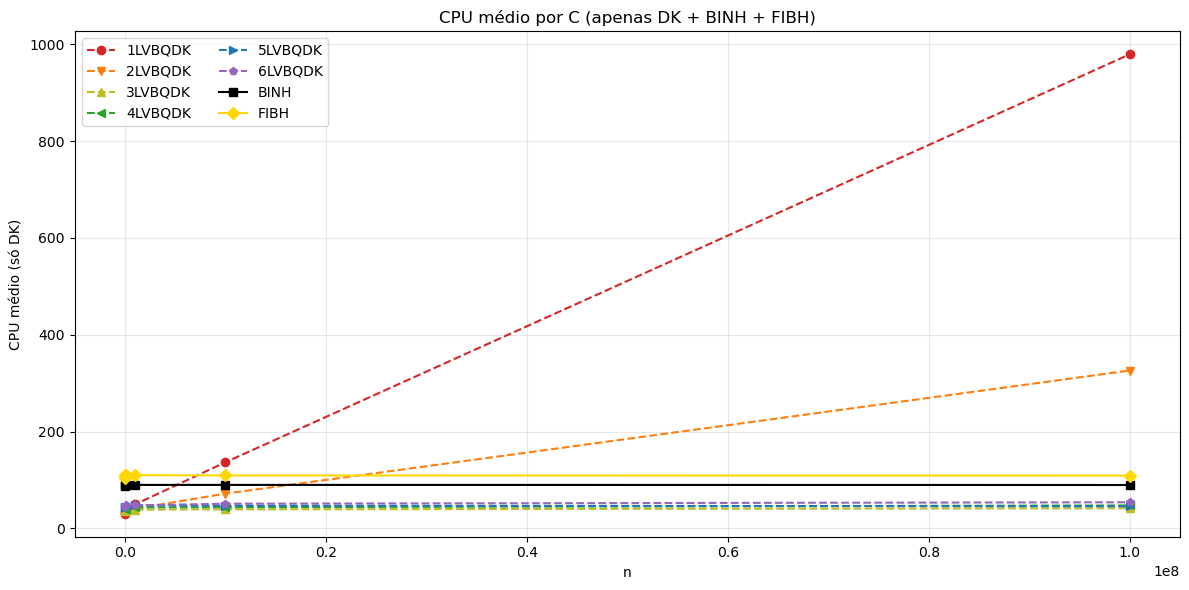

In [29]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **apenas DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQDK$"))  # somente LVBQ DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("c")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ DK (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "--"  # DK → tracejado
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["c"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio (só DK)")
plt.title("CPU médio por C (apenas DK + BINH + FIBH)")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Operações

In [30]:
df_ops = df_tcache.copy()

In [31]:
df_ops["extractMin_extra"] = df_ops["extractMin"] - df_ops["n"]

In [32]:
df_ops = df_tcache.copy()
colunas = [
    "nome", "fila", "n", "c", "insert", "extractMin", "dk", "bkmp",
    "upd", "extractMin_extra"
]
df_mem8 = df_ops[colunas]
df_mem8 = df_mem8[df_mem8["nome"] == "MEM8"]
df_mem8

KeyError: "['extractMin_extra'] not in index"